### Import Libraries

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

### Dataset Loading

In [4]:
# Load Dataset
base_dataset_path = 'dataset'

train_data_dir = os.path.join(base_dataset_path, 'train')
validation_data_dir = os.path.join(base_dataset_path, 'validation')

In [5]:
print(train_data_dir)
print(validation_data_dir)

dataset\train
dataset\validation


#### Viewing images from Training Images Folder

5 random Images in the angry folder out of 3995 total files


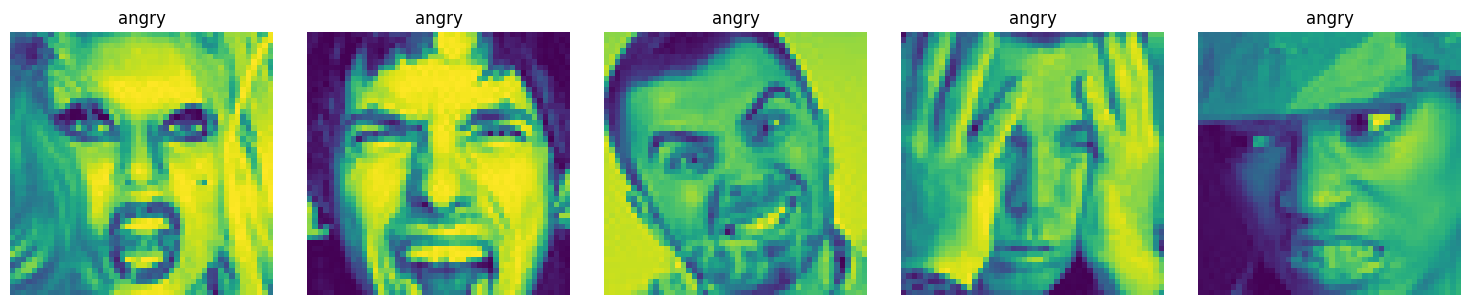

****************************************************************************************************
5 random Images in the disgust folder out of 436 total files


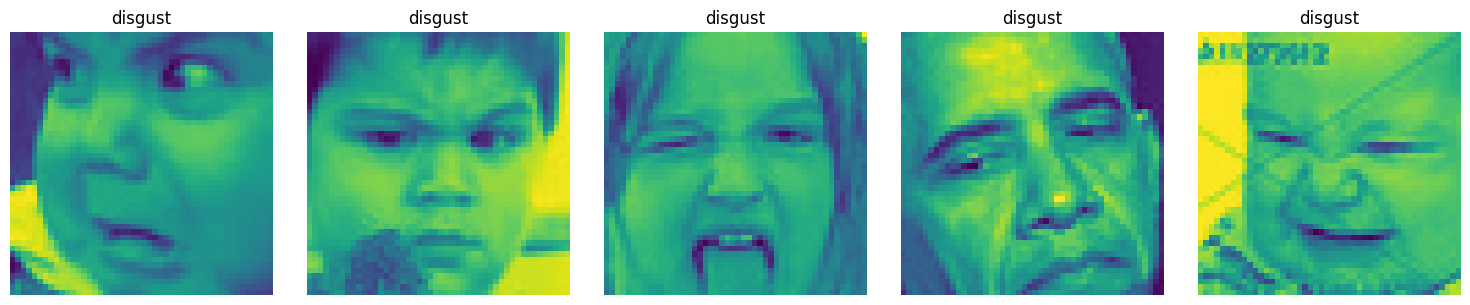

****************************************************************************************************
5 random Images in the fear folder out of 4097 total files


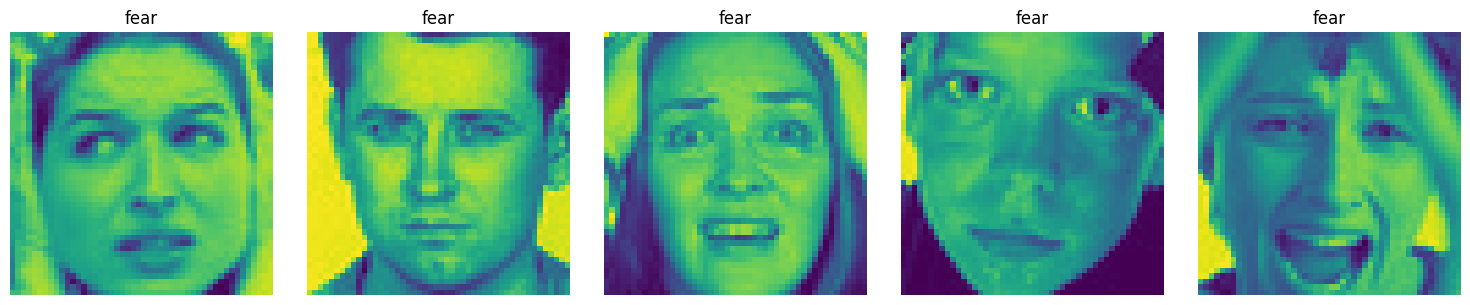

****************************************************************************************************
5 random Images in the happy folder out of 7215 total files


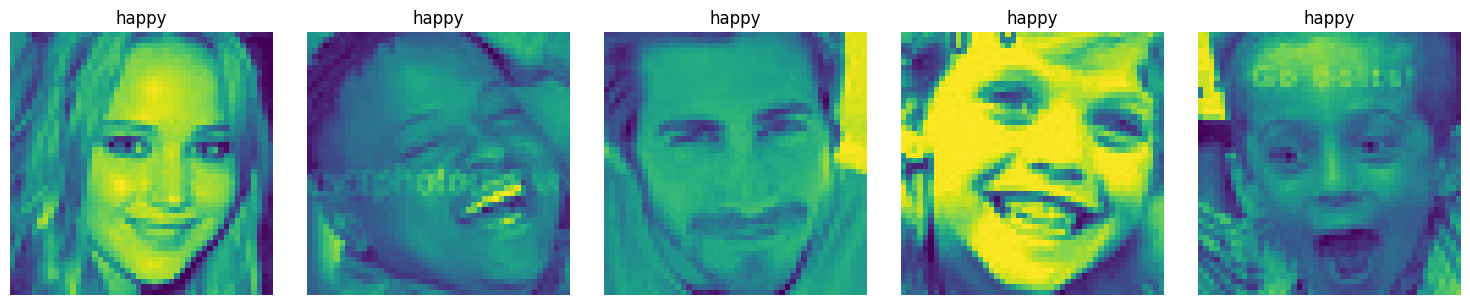

****************************************************************************************************
5 random Images in the neutral folder out of 4965 total files


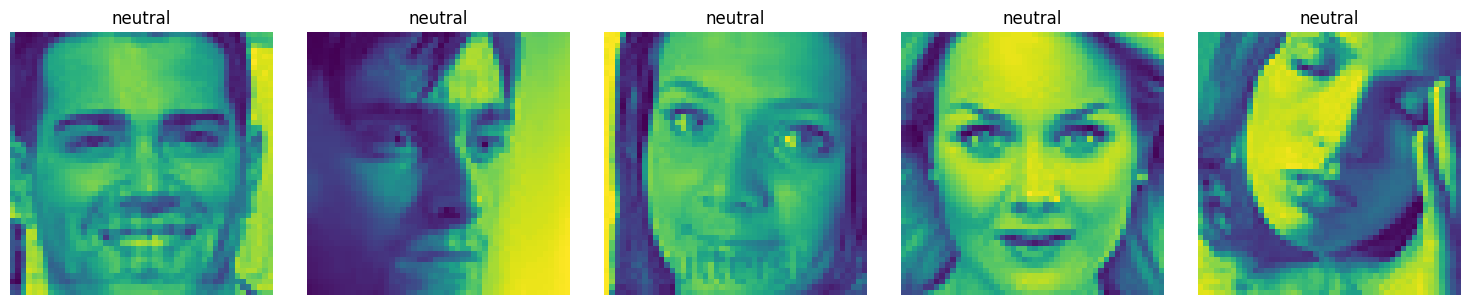

****************************************************************************************************
5 random Images in the sad folder out of 4830 total files


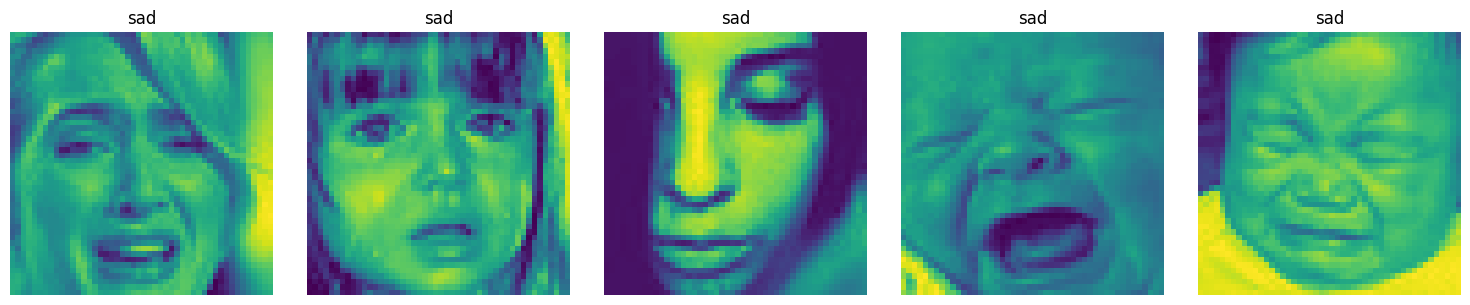

****************************************************************************************************
5 random Images in the surprise folder out of 3171 total files


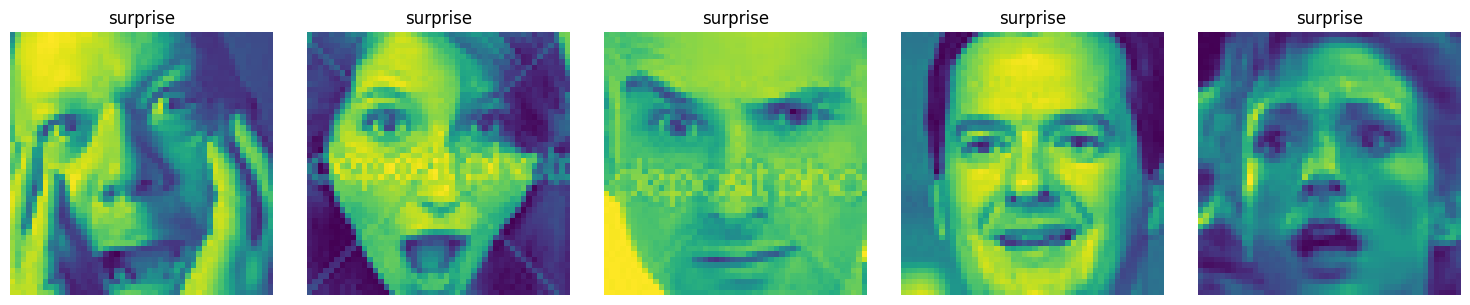

****************************************************************************************************


In [7]:
# Dataset First Look
train_path = 'dataset/train'
train_classes = os.listdir(train_path)

for class_name in train_classes:
    class_dir = os.path.join(train_path, class_name)
    images_files = os.listdir(class_dir)

    print(f"5 random Images in the {class_name} folder out of {len(images_files)} total files")

    random_images = random.sample(images_files, min(5, len(images_files)))

    plt.figure(figsize = (15, 3))
    for index, images in enumerate(random_images):
        img_path = os.path.join(class_dir, images)
        img = Image.open(img_path)

        plt.subplot(1, 5, index+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("*"*100)

#### Viewing images from Validation Images Folder

5 random Images in the angry folder out of 958 total files


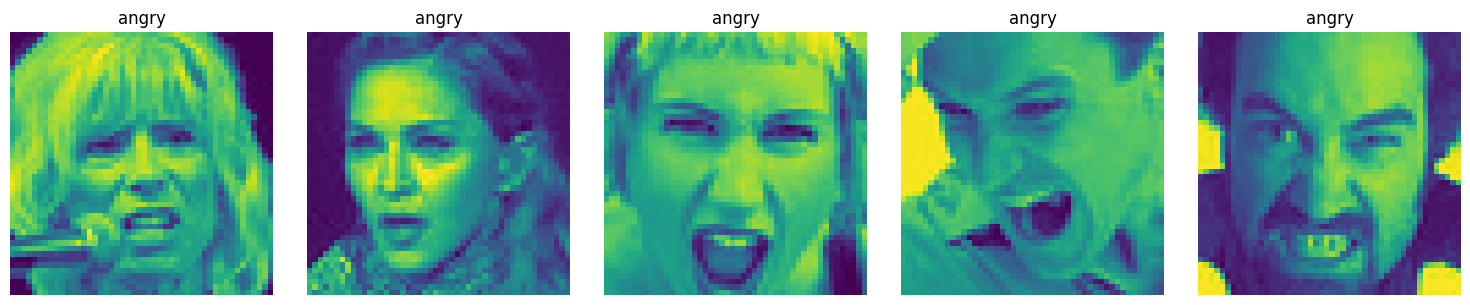

****************************************************************************************************
5 random Images in the disgust folder out of 111 total files


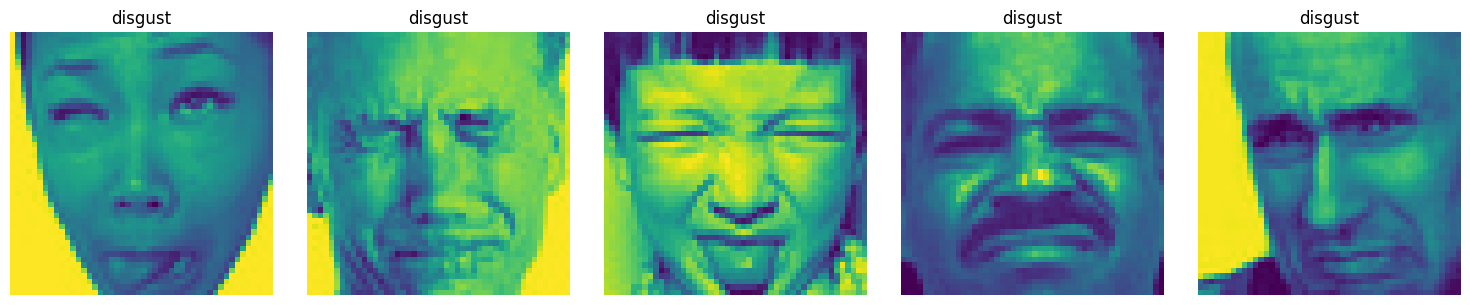

****************************************************************************************************
5 random Images in the fear folder out of 1024 total files


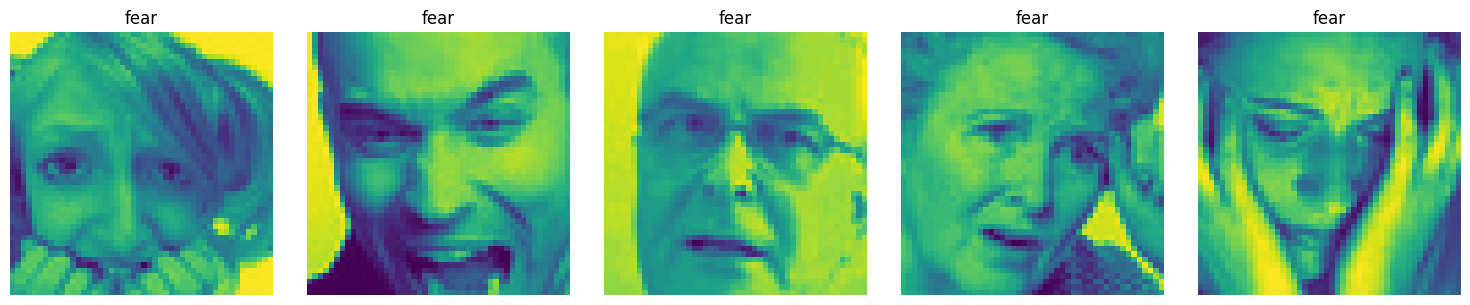

****************************************************************************************************
5 random Images in the happy folder out of 1774 total files


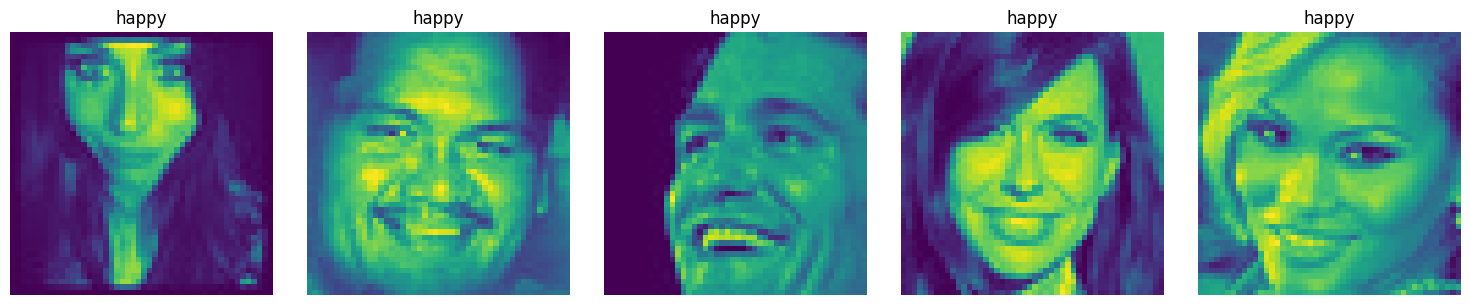

****************************************************************************************************
5 random Images in the neutral folder out of 1233 total files


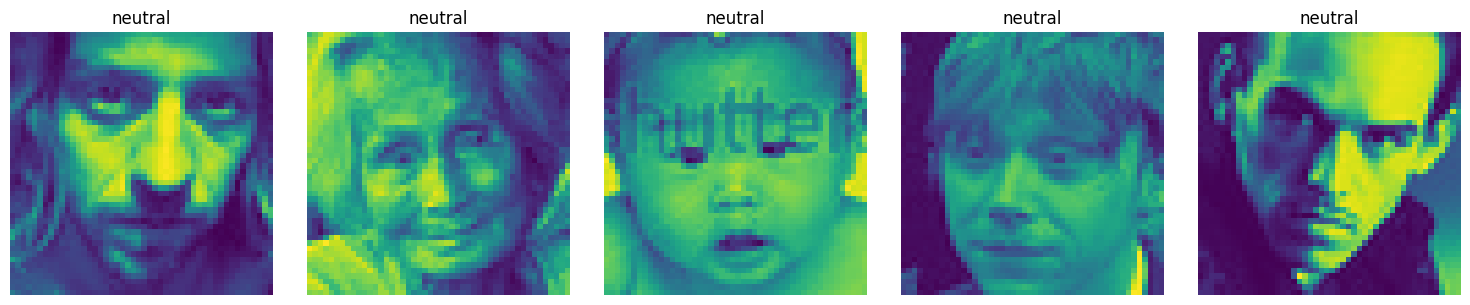

****************************************************************************************************
5 random Images in the sad folder out of 1247 total files


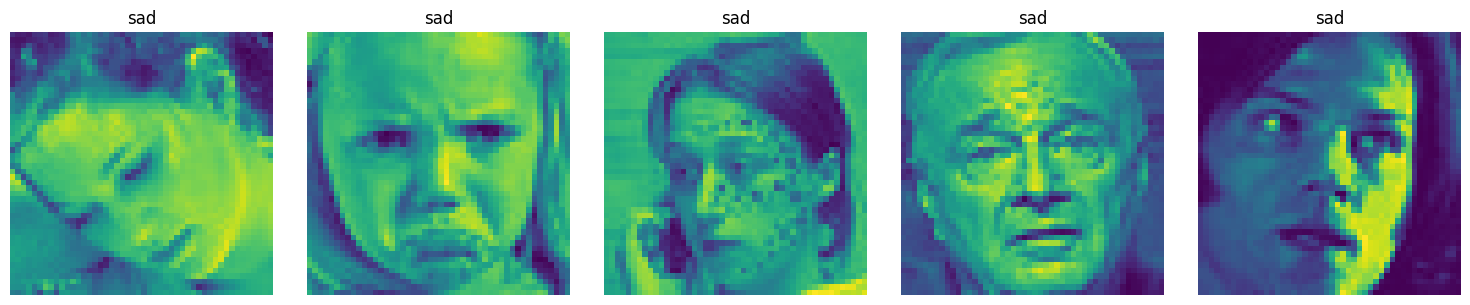

****************************************************************************************************
5 random Images in the surprise folder out of 831 total files


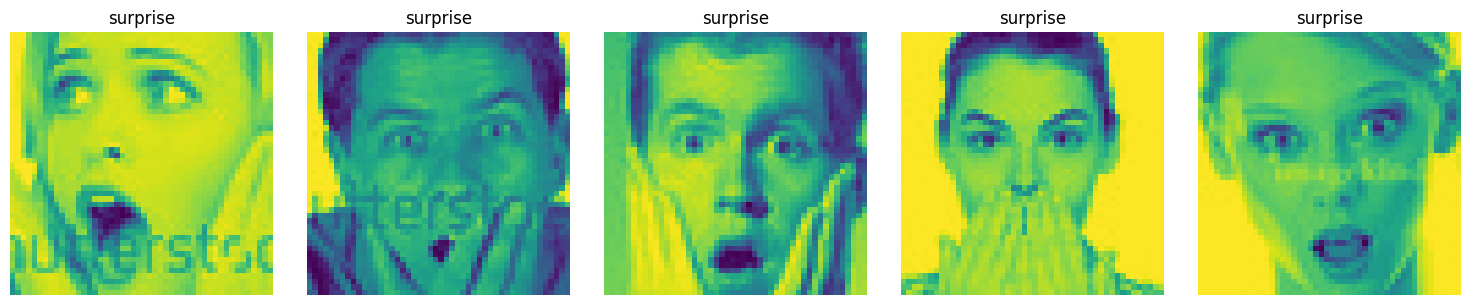

****************************************************************************************************


In [9]:
# Validation Dataset First Look
val_path = 'dataset/validation'
val_classes = os.listdir(val_path)

for class_name in val_classes:
    class_dir = os.path.join(val_path, class_name)
    images_files = os.listdir(class_dir)

    print(f"5 random Images in the {class_name} folder out of {len(images_files)} total files")

    random_images = random.sample(images_files, min(5, len(images_files)))

    plt.figure(figsize = (15, 3))
    for index, images in enumerate(random_images):
        img_path = os.path.join(class_dir, images)
        img = Image.open(img_path)

        plt.subplot(1, 5, index+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("*"*100)

### Images Count

In [11]:
main_dir = 'dataset'
main_dir_files = os.listdir(main_dir)
for sub_dir in main_dir_files:
    class_dir = os.path.join(main_dir, sub_dir)
    class_dir_files = os.listdir(class_dir)
    print("-"*90)
    print(f"Folder inside {sub_dir}: {class_dir_files}")
    print(f"Total Classes in the {sub_dir} folder is: {len(class_dir_files)}")

    total_images = 0
    for files in class_dir_files:
        files_dir  =  os.path.join(class_dir, files)
        images_count = len(os.listdir(files_dir))
        total_images+=images_count
        print(f"Count of images inside {files} : {images_count}")
    print()
    print(f"Total images in {sub_dir} Folder : {total_images}")
    print()

------------------------------------------------------------------------------------------
Folder inside train: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total Classes in the train folder is: 7
Count of images inside angry : 3995
Count of images inside disgust : 436
Count of images inside fear : 4097
Count of images inside happy : 7215
Count of images inside neutral : 4965
Count of images inside sad : 4830
Count of images inside surprise : 3171

Total images in train Folder : 28709

------------------------------------------------------------------------------------------
Folder inside validation: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total Classes in the validation folder is: 7
Count of images inside angry : 958
Count of images inside disgust : 111
Count of images inside fear : 1024
Count of images inside happy : 1774
Count of images inside neutral : 1233
Count of images inside sad : 1247
Count of images inside surprise : 831

To

### Dataset Information

#### Duplicate Images

In [12]:
import os
import hashlib

def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()

# Function to find duplicate images
def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dups = find_duplicates('dataset')
print(f"Total duplicate files found: {len(dups)}")

Total duplicate files found: 1853


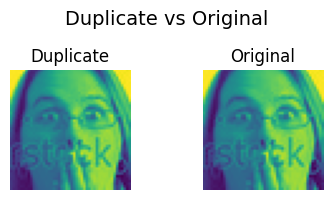

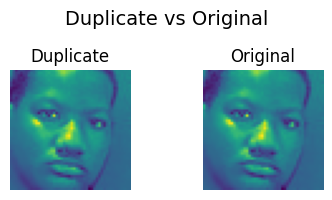

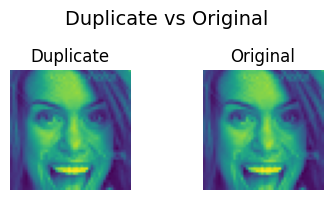

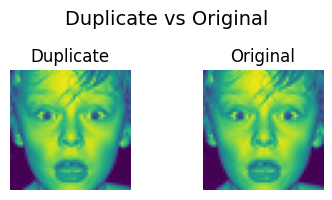

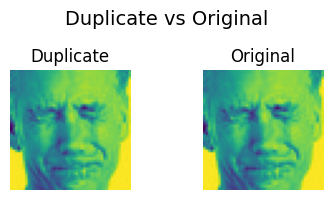

In [13]:
# Randomly sample up to 5 duplicate pairs
random_images = random.sample(dups, min(5, len(dups)))

for dup_path, original_path in random_images:
    try:
        dup_img = Image.open(dup_path)
        orig_img = Image.open(original_path)

        plt.figure(figsize=(4, 2))

        plt.subplot(1, 2, 1)
        plt.imshow(dup_img)
        plt.title("Duplicate")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(orig_img)
        plt.title("Original")
        plt.axis('off')

        plt.suptitle("Duplicate vs Original", fontsize=14)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not open images: {dup_path}, {original_path} → {e}")

In [ ]:
import os
import hashlib

# Function to calculate the MD5 hash of a file
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file_data = f.read()
        hasher.update(file_data)
    return hasher.hexdigest()

# Function to find duplicates across all folders and classes
def find_duplicates_with_classes(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                class_name = os.path.basename(os.path.dirname(file_path))

                if file_hash in hashes:
                    original_path = hashes[file_hash]['path']
                    original_class = hashes[file_hash]['class']

                    duplicates.append({
                        'duplicate_path': file_path,
                        'duplicate_class': class_name,
                        'original_path': original_path,
                        'original_class': original_class
                    })
                else:
                    hashes[file_hash] = {'path': file_path, 'class': class_name}

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

    return duplicates


duplicates = find_duplicates_with_classes('dataset')

# Print results
print(f"Total duplicate files found: {len(duplicates)}\n")

duplicates_different_classes = 0
for dup in duplicates:
    if dup['duplicate_class'] != dup['original_class']:
        duplicates_different_classes+=1
        print(f"Duplicate Image : {dup['duplicate_path']} (Class: {dup['duplicate_class']})")
        print(f"Original Image  : {dup['original_path']} (Class: {dup['original_class']})")
print()
print("-"*90)
print("Total Number of duplicates with different classes :", duplicates_different_classes)

#### Corrupt Images

In [ ]:
# Missing Values/Null Values Count
from PIL import Image

def check_missing_or_corrupt_images(directory):
    corrupt_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                corrupt_images.append(path)

    print(f"Corrupt or Unreadable Images: {len(corrupt_images)}")
    return corrupt_images

# Check both train and validation sets
corrupt_train = check_missing_or_corrupt_images(train_data_dir)
corrupt_val = check_missing_or_corrupt_images(validation_data_dir)


## ***Data Wrangling***

##### Removing the duplicate images from the preprocessed folder which is the copy of the original images folder. It is done to ensure that the initial set of images remain untouched.

In [ ]:
import os
import hashlib

def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()

# Function to find duplicate images
def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dups = find_duplicates('preprocessed_images')
print(f"Total duplicate files found: {len(dups)}")

In [ ]:
# Delete duplicates
for dup in dups:
    duplicate_file = dup[0]

    if os.path.exists(duplicate_file):
        try:
            os.remove(duplicate_file)
            print(f"Deleted: {duplicate_file}")

        except Exception as e:
            print(f"Error deleting {duplicate_file}: {e}")

    else:
        print(f"File already deleted or not found: {duplicate_file}")

print("\nAll duplicate images deletion check completed!")


##### Comparison before and after deleting the images

In [ ]:
import os
import pandas as pd

data = []

def count_images(main_dir, phase):
    main_dir_files = os.listdir(main_dir)
    for sub_dir in main_dir_files:
        class_dir = os.path.join(main_dir, sub_dir)
        class_dir_files = os.listdir(class_dir)

        total_images_in_folder = 0

        for files in class_dir_files:
            files_dir = os.path.join(class_dir, files)
            images_count = len(os.listdir(files_dir))

            total_images_in_folder += images_count

            data.append({
                'Main Folder': sub_dir,
                'Class': files,
                'Images Count': images_count,
                'Phase': phase
            })

        # Append total count for the folder
        data.append({
            'Main Folder': sub_dir,
            'Class': 'Total',
            'Images Count': total_images_in_folder,
            'Phase': phase
        })

count_images('original_images', 'Before')
count_images('preprocessed_images', 'After')

df = pd.DataFrame(data)
comparison_df = df.pivot_table(index=['Main Folder', 'Class'],
                               columns='Phase',
                               values='Images Count',
                               fill_value=0).reset_index()
comparison_df



##### Unique data type of files found inside the folder

In [ ]:
# checking the unique file formats i have in these folders
def check_unique_file_formats(folder_path):
    extensions = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_extension = os.path.splitext(file)[1]
            if file_extension not in extensions:
                extensions.append(file_extension)
        print(f"Unique files in {root}: {extensions}")
        print("-"*80)

folder_path = 'original_images'
check_unique_file_formats(folder_path)

##### Unique Images pixel found inside every folder

In [ ]:
# checking the unique images size
def check_image_size(folder_path):
    size = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            image_path = os.path.join(root, file)
            with Image.open(image_path) as img:
                image_size = img.size
            if image_size not in size:
                size.append(image_size)

        print(f"Unique image size in {root}: {size}")
        print("-"*80)

folder_path = 'original_images'
check_image_size(folder_path)

##### Unique type of Image file size found inside different folder

In [ ]:
# Set your directory path
base_path = "original_images"

file_data = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            size_kb = os.path.getsize(file_path) / 1024
            file_data.append({
                "file_name": file,
                "folder": os.path.relpath(root, base_path),
                "size_kb": round(size_kb, 2)
            })
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Create DataFrame
df = pd.DataFrame(file_data)

# Sort by size to detect anomalies
df_sorted = df.sort_values(by="size_kb", ascending=False)
df_sorted

In [ ]:
print("Unique File Sizes (KB):")
print(df["size_kb"].unique())
print("Total Files Scanned:", len(df))


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code
def plot_class_distribution(directory, title):
    classes = os.listdir(directory)
    counts = [len(os.listdir(os.path.join(directory, cls))) for cls in classes]

    plt.figure(figsize=(8, 5))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Emotion Classes')
    plt.ylabel('Number of Images')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_data_dir, 'Training Set: Class Distribution')
plot_class_distribution(validation_data_dir, 'Validation Set: Class Distribution')
